In [81]:
# Подключаем необходимые библиотеки
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import os

In [82]:
# Подключаем датасет
url="https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/refs/heads/main/seminars/S02/S02-hw-dataset.csv"
df = pd.read_csv(url, sep=',')

# Выводим первые две строки датасета
df.head(2)

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115


In [83]:
# Вывод информации о столбцах датасета
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [84]:
# Вывод базовой описательной статитстики датасета
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


В данном датасете были обнаружены некачественные данные: полнота, уникальность и валидность. В поле "user_id" нарушена уникальность, в поле "country" нарушена полнота, а в остальных валидация 

In [85]:
# Считаем кол-во пропусков в полях датасета
propysk = df["user_id"].isna().sum() + df["age"].isna().sum() + df["country"].isna().sum() + df["purchases"].isna().sum() + df["revenue"].isna().sum()

# Находим кол-во дубликатов
duplicated_data = df.duplicated().sum()

# Для проверки вывел индекс строки, в которой был найден дубликат
duplicated_indices = df[df.duplicated(keep='first')].index.tolist()

# Проверка на отрицателные значения в поле 'user_id'
strange_user_id = (df["user_id"] < 0).sum()

# Проверка кол-ва не валидных данных в поле 'age'
srange_age = ((df["age"] < 0) | (df["age"] > 100)).sum()

# Проверка на страны с длиной, отличной от 2, или неверным типом данных (например, числа)
strange_country = ((df["country"].str.len() != 2) | (isinstance(df["country"], str) | (not isinstance(df["country"],(int, float))) )).sum()

# Проверка на отрицательные занчаения в поле покупки
strange_purchases = (df["purchases"] < 0).sum()

# Проверка на отрицательные занчаения в поле доходы
strange_revenue = ((df["revenue"] <= 0)).sum()

# Вывод результатов  
print("Индекс дубликатов:", duplicated_indices)
print(f"Количество пропусков в данных: {propysk}, количество дубликатов: {duplicated_data}, количество странных user_id: {strange_user_id}, количество странных age: {srange_age}, количество странных country: {strange_country}, количество странных purchases: {strange_purchases}, количество странных revenue: {strange_revenue}")

Индекс дубликатов: [40]
Количество пропусков в данных: 2, количество дубликатов: 1, количество странных user_id: 0, количество странных age: 1, количество странных country: 41, количество странных purchases: 1, количество странных revenue: 4


In [86]:
# Распределяем возрасты по группам используя метод корзин 'bins'
cat_age = df["age"].value_counts(bins=[1, 25, 45, 65, 100], sort=False)

# Находим частоту встречаемости стран
cat_country = df["country"].value_counts(sort=True)

# Находим средний возраст по странам
group_by_country = (df.groupby("country")["age"].mean()).round(1)

# Находим суммарные покупки по странам
group_by_purchases = df.groupby("country")["purchases"].sum()


# Выврд
print("\n1. Распределение возраста по группам:")
print(cat_age.to_string())

print("\n2. Частота встречаемости стран:")
print(cat_country.to_string())

print("\n3. Средний возраст по странам:")
print(group_by_country.to_string())

print("\n4. Суммарные покупки по странам:")
print(group_by_purchases.to_string())


1. Распределение возраста по группам:
(0.999, 25.0]    12
(25.0, 45.0]     17
(45.0, 65.0]      9
(65.0, 100.0]     0

2. Частота встречаемости стран:
country
RU    13
FR    12
US     8
DE     6
CN     2

3. Средний возраст по странам:
country
CN    24.0
DE    34.6
FR    46.2
RU    30.1
US    36.7

4. Суммарные покупки по странам:
country
CN     9
DE    39
FR    51
RU    62
US    37


В категориальных данных: в возрасте доминируют люди входящие в возратсной дипазон от 25 до 45 и больше всего встречается пользователей из России.

Группы отличаются по средним значениям: минимальный средний возраст и максимальный средний возраст. В CN 24.0, а в FR 46.2.

Неожиданных эффектов не обнаружено.

In [87]:
save_dir = r'c:\Users\edikf\OneDrive\Рабочий стол\AI-course\homeworks\HW02\figures'

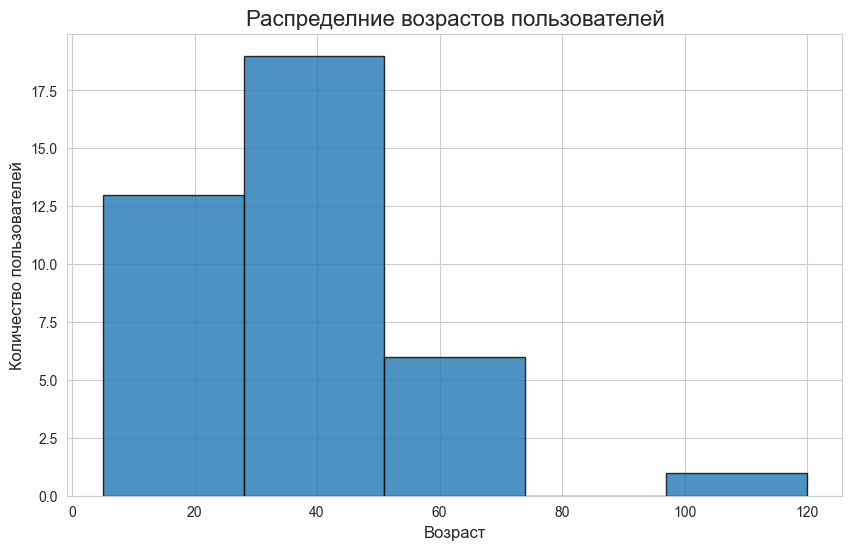

In [88]:
# Выбор поля в датасете, по которому будем строить гистограмму
data_for_hist = df['age']

# Размер изображения
plt.figure(figsize=(10, 6))

# Данные по которым строим график
plt.hist(data_for_hist, bins=5, edgecolor='black', alpha=0.8)

# Настройка визуализации графика
plt.title("Распределние возрастов пользователей", fontsize=16)
plt.xlabel("Возраст", fontsize=12)
plt.ylabel("Количество пользователей", fontsize=12)



# Сохранение графика в папку
path1 = r'c:\Users\edikf\OneDrive\Рабочий стол\AI-course\homeworks\HW02\figures\histogramm_age.png'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(path1)

# Вывод графика
plt.show()

# Закрытие буфера
plt.close()


C:\Users\edikf\AppData\Local\Temp\ipykernel_6432\4075654748.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y='revenue', palette='viridis', data=df)


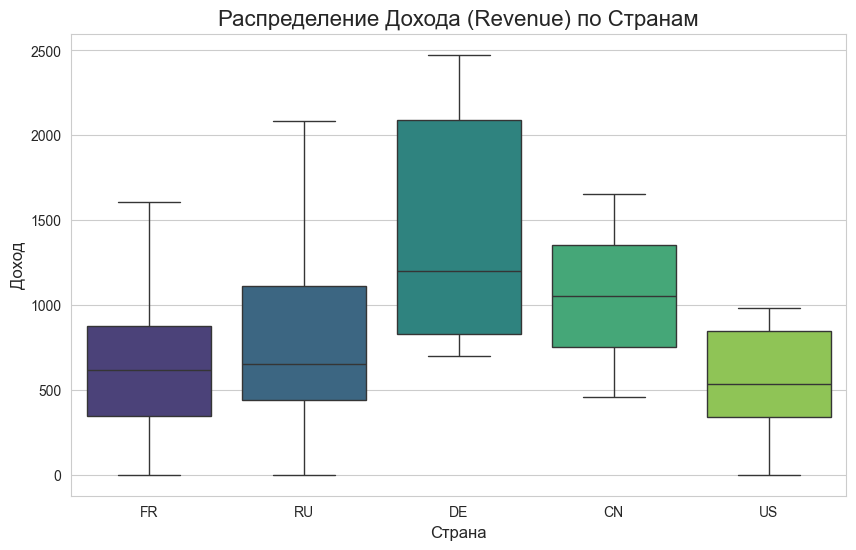

In [89]:
# Выбор поля в датасете, по которому будем строить боксплот
sns.set_style('whitegrid')

# Размер изображения
plt.figure(figsize=(10, 6))

# Данные по которым строим график
sns.boxplot(x='country', y='revenue', palette='viridis', data=df)

# Настройка визуализации графика
plt.title('Распределение Дохода (Revenue) по Странам', fontsize=16)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Доход', fontsize=12)



# Сохранение графика в папку
path2 = r'c:\Users\edikf\OneDrive\Рабочий стол\AI-course\homeworks\HW02\figures\boxplot_country_revenue.png'
plt.savefig(path2)


# Вывод графика
plt.show()

# Закрытие буфера
plt.close()


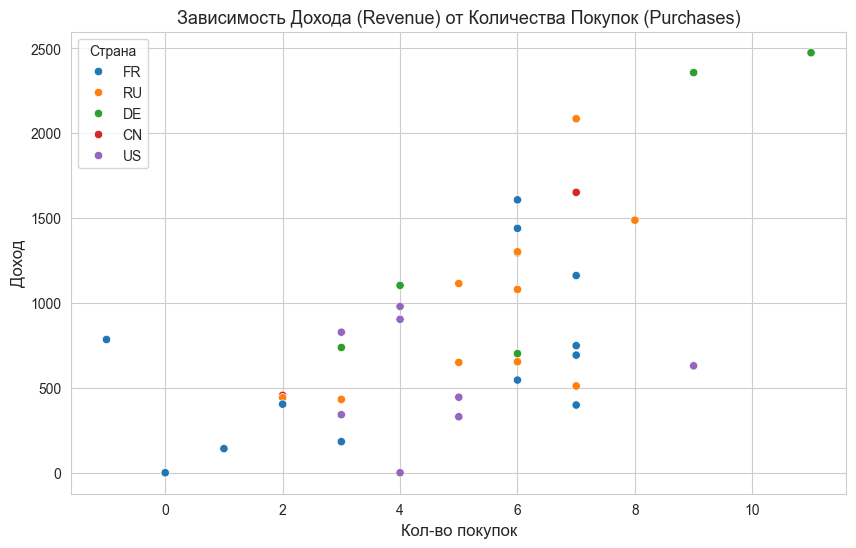

In [90]:
# Выбор поля в датасете, по которому будем строить диаграмму рассеяния
sns.set_style("whitegrid")

# Размер изображения
plt.figure(figsize=(10, 6))

# Данные по которым строим график
sns.scatterplot(x="purchases", y="revenue", hue="country", data=df)

# Настройка визуализации графика
plt.title("Зависимость Дохода (Revenue) от Количества Покупок (Purchases)", fontsize=13)
plt.xlabel("Кол-во покупок", fontsize=12)
plt.ylabel("Доход", fontsize=12)
plt.legend(title='Страна')


# Сохранение графика в папку
path3 = r'c:\Users\edikf\OneDrive\Рабочий стол\AI-course\homeworks\HW02\figures\scatter_purchases_revenue.png'
plt.savefig(path3)

# Вывод графика
plt.show()

# Закрытие буфера
plt.close()
